# Flat bands from the `extkag_1_*_shb.csv` simulations

Extract the 14 lowest-frequency bands from every matching COMSOL CSV export. The highest-frequency retained band is treated as the flat band.

In [1]:
import csv
import re
from collections import defaultdict
from pathlib import Path

from IPython.display import Markdown, display
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import numpy as np

## Discover the simulation files

In [2]:
# The first path is correct when the notebook runs from its own directory;
# the second also permits execution from the repository root.
data_dir = next(
    path.resolve()
    for path in (Path('../../../data/simulation'), Path('data/simulation'))
    if path.is_dir()
)

filename_pattern = re.compile(r'^extkag_1(.+)shb\.csv$')
band_files = {}

for csv_path in data_dir.glob('extkag_1*shb.csv'):
    match = filename_pattern.match(csv_path.name)
    if match is None:
        continue

    label = match.group(1)
    if label in band_files:
        raise ValueError(f'Multiple files found for {label!r}')
    band_files[label] = csv_path

band_files = dict(sorted(band_files.items()))
if not band_files:
    raise FileNotFoundError(
        f'No extkag_1_*_shb.csv files found in {data_dir}'
    )

print(f'Found {len(band_files)} band-structure files:')
for label, csv_path in band_files.items():
    print(f'  {label}: {csv_path.name}')

Found 15 band-structure files:
  _: extkag_1_shb.csv
  _coarse_: extkag_1_coarse_shb.csv
  _coarse_cm_: extkag_1_coarse_cm_shb.csv
  _extrafine_: extkag_1_extrafine_shb.csv
  _extrafine_cm_: extkag_1_extrafine_cm_shb.csv
  _extremelyfine_: extkag_1_extremelyfine_shb.csv
  _extremelyfine_cm_: extkag_1_extremelyfine_cm_shb.csv
  _face_union_: extkag_1_face_union_shb.csv
  _face_union_lattice_: extkag_1_face_union_lattice_shb.csv
  _fine_: extkag_1_fine_shb.csv
  _fine_cm_: extkag_1_fine_cm_shb.csv
  _finer_: extkag_1_finer_shb.csv
  _finer_cm_: extkag_1_finer_cm_shb.csv
  _normal_: extkag_1_normal_shb.csv
  _normal_cm_: extkag_1_normal_cm_shb.csv


## Choose simulation files to omit

In [3]:
# Add exact CSV filenames to this set to exclude them from all analysis.
OMIT_FILES = set((
    'extkag_1_face_union_shb.csv',
    'extkag_1_face_union_lattice_shb.csv',
    'extkag_1_shb.csv',
))

available_files = {csv_path.name for csv_path in band_files.values()}
unknown_omit_files = OMIT_FILES - available_files
if unknown_omit_files:
    raise ValueError(
        'Files selected for omission were not found: '
        + ', '.join(sorted(unknown_omit_files))
    )

band_files = {
    label: csv_path
    for label, csv_path in band_files.items()
    if csv_path.name not in OMIT_FILES
}
if not band_files:
    raise ValueError('All discovered simulation files were omitted')

if OMIT_FILES:
    print('Omitting: ' + ', '.join(sorted(OMIT_FILES)))
else:
    print('No simulation files omitted.')

Omitting: extkag_1_face_union_lattice_shb.csv, extkag_1_face_union_shb.csv, extkag_1_shb.csv


## Extract and organize the 14 lowest eigenfrequency bands

In [4]:
BAND_COUNT = 14

UNIT_TO_HZ = {
    'hz': 1.0,
    'khz': 1.0e3,
    'mhz': 1.0e6,
    'ghz': 1.0e9,
}


def frequency_scale_to_hz(column_name):
    normalized = column_name.casefold().replace(' ', '')
    for unit, scale in UNIT_TO_HZ.items():
        if f'({unit})' in normalized:
            return scale
    raise ValueError(f'Could not identify the unit in {column_name!r}')


def real_part(value):
    return complex(value.strip().replace('i', 'j')).real


def extract_eigenfrequencies(csv_path, band_count=BAND_COUNT):
    b_index = None
    eigenfrequency_index = None
    scale_to_hz = None
    frequencies_by_b = defaultdict(list)

    with Path(csv_path).open(newline='', encoding='utf-8-sig') as csv_file:
        for row in csv.reader(csv_file):
            if not row:
                continue

            if row[0].lstrip().startswith('%'):
                header = [cell.strip().lstrip('% ') for cell in row]
                frequency_columns = [
                    index for index, name in enumerate(header)
                    if name.casefold().startswith('eigenfrequency')
                ]
                if frequency_columns:
                    eigenfrequency_index = frequency_columns[-1]
                    scale_to_hz = frequency_scale_to_hz(
                        header[eigenfrequency_index]
                    )
                    b_columns = [
                        index for index, name in enumerate(header)
                        if name.casefold() == 'b'
                    ]
                    if not b_columns:
                        raise ValueError(f'No b column found in {csv_path}')
                    b_index = b_columns[0]
                continue

            if b_index is None or eigenfrequency_index is None:
                raise ValueError(
                    f'No Eigenfrequency column found in {csv_path}'
                )

            b_value = float(row[b_index])
            frequency_hz = (
                real_part(row[eigenfrequency_index]) * scale_to_hz
            )
            frequencies_by_b[b_value].append(frequency_hz)

    if not frequencies_by_b:
        raise ValueError(f'No eigenfrequencies found in {csv_path}')

    insufficient_b_values = [
        b_value for b_value, frequencies in frequencies_by_b.items()
        if len(frequencies) < band_count
    ]
    if insufficient_b_values:
        raise ValueError(
            f'{csv_path} has fewer than {band_count} bands at '
            f'{len(insufficient_b_values)} b values'
        )

    b_values = np.asarray(sorted(frequencies_by_b))
    bands_hz = np.stack([
        np.sort(frequencies_by_b[b_value])[:band_count]
        for b_value in b_values
    ])

    return {
        'b': b_values,
        'bands_hz': bands_hz,
    }


band_data = {
    label: extract_eigenfrequencies(csv_path)
    for label, csv_path in band_files.items()
}

for label, dataset in band_data.items():
    b_count, band_count = dataset['bands_hz'].shape
    print(
        f'{label}: selected the {band_count} lowest bands '
        f'at {b_count} b values'
    )

_coarse_: selected the 14 lowest bands at 48 b values
_coarse_cm_: selected the 14 lowest bands at 48 b values
_extrafine_: selected the 14 lowest bands at 48 b values
_extrafine_cm_: selected the 14 lowest bands at 48 b values
_extremelyfine_: selected the 14 lowest bands at 48 b values
_extremelyfine_cm_: selected the 14 lowest bands at 48 b values
_fine_: selected the 14 lowest bands at 48 b values
_fine_cm_: selected the 14 lowest bands at 48 b values
_finer_: selected the 14 lowest bands at 48 b values
_finer_cm_: selected the 14 lowest bands at 48 b values
_normal_: selected the 14 lowest bands at 48 b values
_normal_cm_: selected the 14 lowest bands at 48 b values


## Plot and measure the flat bands

At every path coordinate, the flat band is the highest-frequency band among the 14 retained bands. The reported flat-band frequency is its mean across all sampled path coordinates; its bandwidth is $f_\mathrm{max}-f_\mathrm{min}$. The bandgap is the global spectral separation between the flat band and the highest-frequency dispersive band below it; overlapping bands are reported as a zero gap.

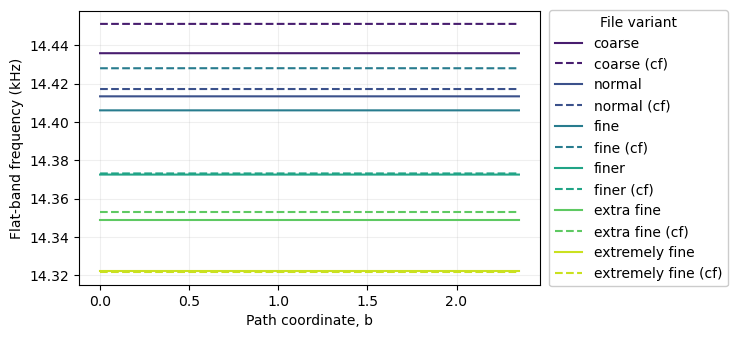

| File variant | Mean frequency (kHz) | Minimum frequency (kHz) | Maximum frequency (kHz) | Bandwidth (mHz) | Bandgap (Hz) |
|:--|--:|--:|--:|--:|--:|
| coarse | 14.435864557 | 14.435862816 | 14.435866705 | 3.889084959 | 176.650507827 |
| coarse (cf) | 14.451155957 | 14.451155636 | 14.451156828 | 1.192545211 | 170.778371860 |
| normal | 14.413364251 | 14.413363916 | 14.413364687 | 0.771061601 | 177.225261866 |
| normal (cf) | 14.417179316 | 14.417177001 | 14.417180859 | 3.858709053 | 177.026577808 |
| fine | 14.406052473 | 14.406052074 | 14.406052883 | 0.809245386 | 170.439933018 |
| fine (cf) | 14.428028307 | 14.428013354 | 14.428040840 | 27.485336670 | 175.111957581 |
| finer | 14.372552270 | 14.372551837 | 14.372552857 | 1.020166070 | 180.478128400 |
| finer (cf) | 14.373135728 | 14.373134094 | 14.373137996 | 3.902329492 | 181.004807621 |
| extra fine | 14.349097395 | 14.349097230 | 14.349097678 | 0.447467919 | 180.463445874 |
| extra fine (cf) | 14.353141209 | 14.353141120 | 14.353141318 | 0.197480680 | 180.478020299 |
| extremely fine | 14.322252653 | 14.322252630 | 14.322252679 | 0.048798518 | 179.718540996 |
| extremely fine (cf) | 14.321563537 | 14.321563517 | 14.321563552 | 0.034390441 | 179.161753366 |

In [5]:
flat_band_metrics = {}


variant_names = {
    label: label.strip('_') or 'normal' for label in band_data
}
available_variant_names = set(variant_names.values())


def mesh_variant(label):
    variant_name = variant_names[label]
    mesh_complexity, separator, variant_suffix = (
        variant_name.rpartition('_')
    )
    is_cf = (
        separator == '_'
        and len(variant_suffix) == 2
        and mesh_complexity in available_variant_names
    )
    if not is_cf:
        mesh_complexity = variant_name
    return mesh_complexity, is_cf


MESH_ORDER = (
    'coarse',
    'normal',
    'fine',
    'finer',
    'extrafine',
    'extremelyfine',
)
MESH_ORDER_INDEX = {
    mesh_complexity: index
    for index, mesh_complexity in enumerate(MESH_ORDER)
}
MESH_DISPLAY_NAMES = {
    'extrafine': 'extra fine',
    'extremelyfine': 'extremely fine',
}


def mesh_display_name(mesh_complexity):
    return MESH_DISPLAY_NAMES.get(
        mesh_complexity, mesh_complexity.replace('_', ' ')
    )


def mesh_sort_key(label):
    mesh_complexity, is_cf = mesh_variant(label)
    return (
        MESH_ORDER_INDEX.get(mesh_complexity, len(MESH_ORDER)),
        mesh_complexity,
        is_cf,
    )


ordered_labels = sorted(band_data, key=mesh_sort_key)
mesh_complexities = list(dict.fromkeys(
    mesh_variant(label)[0] for label in ordered_labels
))
mesh_colormap = plt.colormaps['viridis']
mesh_color_values = np.linspace(0.08, 0.92, len(mesh_complexities))
mesh_colors = {
    mesh_complexity: mesh_colormap(color_value)
    for mesh_complexity, color_value in zip(
        mesh_complexities, mesh_color_values
    )
}

fig, ax = plt.subplots(figsize=(7.5, 3.5), tight_layout=True)
for label in ordered_labels:
    dataset = band_data[label]
    flat_band_hz = dataset['bands_hz'][:, -1]
    highest_dispersive_hz = dataset['bands_hz'][:, :-1].max()
    flat_band_metrics[label] = {
        'mean_hz': flat_band_hz.mean(),
        'minimum_hz': flat_band_hz.min(),
        'maximum_hz': flat_band_hz.max(),
        'bandwidth_hz': np.ptp(flat_band_hz),
        'highest_dispersive_hz': highest_dispersive_hz,
        'bandgap_hz': max(
            0.0, flat_band_hz.min() - highest_dispersive_hz
        ),
    }
    mesh_complexity, is_cf = mesh_variant(label)
    display_label = mesh_display_name(mesh_complexity)
    if is_cf:
        display_label += ' (cf)'
    ax.plot(
        dataset['b'], flat_band_hz / 1e3,
        color=mesh_colors[mesh_complexity],
        linestyle='--' if is_cf else '-',
        linewidth=1.5, label=display_label,
    )

ax.set_xlabel('Path coordinate, b')
ax.set_ylabel('Flat-band frequency (kHz)')
ax.grid(alpha=0.2)
handles, legend_labels = ax.get_legend_handles_labels()
legend = ax.legend(
    handles, legend_labels,
    title='File variant', loc='center left',
    bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0,
    frameon=True, facecolor='white', framealpha=1.0,
    edgecolor='0.8',
)
legend.set_zorder(10)
plt.show()

flat_band_metrics_table = [
    '| File variant | Mean frequency (kHz) | Minimum frequency (kHz) | Maximum frequency (kHz) | Bandwidth (mHz) | Bandgap (Hz) |',
    '|:--|--:|--:|--:|--:|--:|',
]
for label, metrics in flat_band_metrics.items():
    mesh_complexity, is_cf = mesh_variant(label)
    display_label = mesh_display_name(mesh_complexity)
    if is_cf:
        display_label += ' (cf)'
    flat_band_metrics_table.append(
        f'| {display_label} '
        f'| {metrics["mean_hz"] / 1e3:.9f} '
        f'| {metrics["minimum_hz"] / 1e3:.9f} '
        f'| {metrics["maximum_hz"] / 1e3:.9f} '
        f'| {metrics["bandwidth_hz"]*1e3:.9f} '
        f'| {metrics["bandgap_hz"]:.9f} |'
    )

display(Markdown('\n'.join(flat_band_metrics_table)))

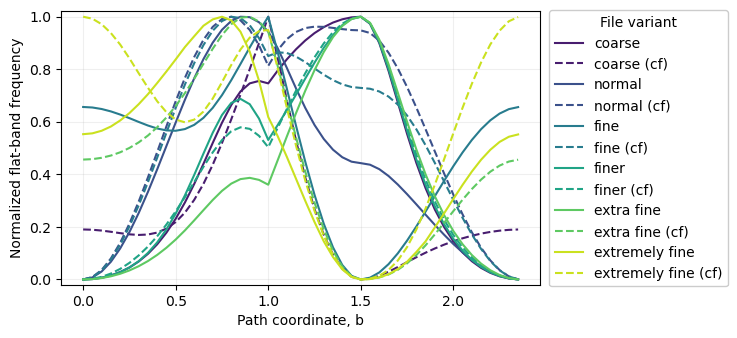

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 3.5), tight_layout=True)
for label in ordered_labels:
    dataset = band_data[label]
    flat_band_hz = dataset['bands_hz'][:, -1]
    bandwidth_hz = flat_band_metrics[label]['bandwidth_hz']
    if bandwidth_hz == 0.0:
        normalized_flat_band = np.zeros_like(flat_band_hz)
    else:
        normalized_flat_band = (
            flat_band_hz - flat_band_hz.min()
        ) / bandwidth_hz

    mesh_complexity, is_cf = mesh_variant(label)
    display_label = mesh_display_name(mesh_complexity)
    if is_cf:
        display_label += ' (cf)'
    ax.plot(
        dataset['b'], normalized_flat_band,
        color=mesh_colors[mesh_complexity],
        linestyle='--' if is_cf else '-',
        linewidth=1.5, label=display_label,
    )

ax.set_ylim(-0.02, 1.02)
ax.set_xlabel('Path coordinate, b')
ax.set_ylabel('Normalized flat-band frequency')
ax.grid(alpha=0.2)
handles, legend_labels = ax.get_legend_handles_labels()
legend = ax.legend(
    handles, legend_labels,
    title='File variant', loc='center left',
    bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0,
    frameon=True, facecolor='white', framealpha=1.0,
    edgecolor='0.8',
)
legend.set_zorder(10)
plt.show()

## Compare paired CF and non-CF bandwidths

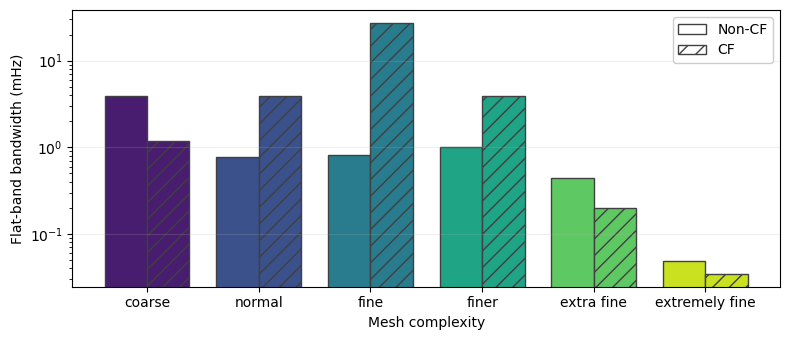

In [7]:
bandwidths_by_mesh = defaultdict(dict)
for label, metrics in flat_band_metrics.items():
    mesh_complexity, is_cf = mesh_variant(label)
    bandwidths_by_mesh[mesh_complexity][is_cf] = (
        metrics['bandwidth_hz'] * 1e3
    )

paired_bandwidths = {
    mesh_complexity: bandwidths
    for mesh_complexity, bandwidths in bandwidths_by_mesh.items()
    if False in bandwidths and True in bandwidths
}
if not paired_bandwidths:
    raise ValueError('No paired CF and non-CF simulation files found')

paired_meshes = [
    mesh_complexity for mesh_complexity in mesh_complexities
    if mesh_complexity in paired_bandwidths
]
paired_mesh_colors = [mesh_colors[mesh] for mesh in paired_meshes]
bar_positions = np.arange(len(paired_meshes))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(8, 3.5), tight_layout=True)
ax.bar(
    bar_positions - bar_width / 2,
    [paired_bandwidths[mesh][False] for mesh in paired_meshes],
    width=bar_width, color=paired_mesh_colors,
    edgecolor='0.25', label='Non-CF',
)
ax.bar(
    bar_positions + bar_width / 2,
    [paired_bandwidths[mesh][True] for mesh in paired_meshes],
    width=bar_width, color=paired_mesh_colors,
    edgecolor='0.25', hatch='//', label='CF',
)

ax.set_xticks(
    bar_positions,
    [mesh_display_name(mesh) for mesh in paired_meshes],
)
ax.set_xlabel('Mesh complexity')
ax.set_ylabel('Flat-band bandwidth (mHz)')
ax.grid(axis='y', alpha=0.2)
bar_legend_handles = [
    Patch(facecolor='white', edgecolor='0.25', label='Non-CF'),
    Patch(
        facecolor='white', edgecolor='0.25',
        hatch='//', label='CF',
    ),
]
ax.legend(
    handles=bar_legend_handles,
    frameon=True, facecolor='white', framealpha=1.0,
    edgecolor='0.8',
)
ax.set_yscale('log')
plt.show()

## Compare paired CF and non-CF bandgaps

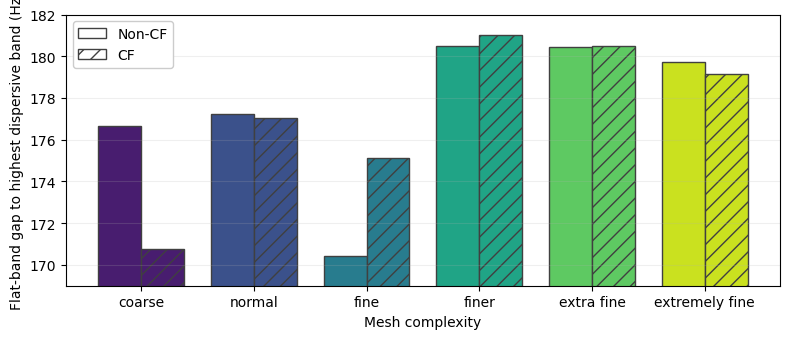

In [8]:
bandgaps_by_mesh = defaultdict(dict)
for label, metrics in flat_band_metrics.items():
    mesh_complexity, is_cf = mesh_variant(label)
    bandgaps_by_mesh[mesh_complexity][is_cf] = (
        metrics['bandgap_hz']
    )

paired_bandgaps = {
    mesh_complexity: bandgaps
    for mesh_complexity, bandgaps in bandgaps_by_mesh.items()
    if False in bandgaps and True in bandgaps
}
if not paired_bandgaps:
    raise ValueError('No paired CF and non-CF simulation files found')

paired_meshes = [
    mesh_complexity for mesh_complexity in mesh_complexities
    if mesh_complexity in paired_bandgaps
]
paired_mesh_colors = [mesh_colors[mesh] for mesh in paired_meshes]
bar_positions = np.arange(len(paired_meshes))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(8, 3.5), tight_layout=True)
ax.bar(
    bar_positions - bar_width / 2,
    [paired_bandgaps[mesh][False] for mesh in paired_meshes],
    width=bar_width, color=paired_mesh_colors,
    edgecolor='0.25', label='Non-CF',
)
ax.bar(
    bar_positions + bar_width / 2,
    [paired_bandgaps[mesh][True] for mesh in paired_meshes],
    width=bar_width, color=paired_mesh_colors,
    edgecolor='0.25', hatch='//', label='CF',
)

ax.set_xticks(
    bar_positions,
    [mesh_display_name(mesh) for mesh in paired_meshes],
)
ax.set_xlabel('Mesh complexity')
ax.set_ylabel('Flat-band gap to highest dispersive band (Hz)')
ax.set_ylim(169.0, 182.0)
ax.grid(axis='y', alpha=0.2)
bar_legend_handles = [
    Patch(facecolor='white', edgecolor='0.25', label='Non-CF'),
    Patch(
        facecolor='white', edgecolor='0.25',
        hatch='//', label='CF',
    ),
]
ax.legend(
    handles=bar_legend_handles,
    frameon=True, facecolor='white', framealpha=1.0,
    edgecolor='0.8',
)
plt.show()

## Compare paired CF and non-CF flat-band frequencies

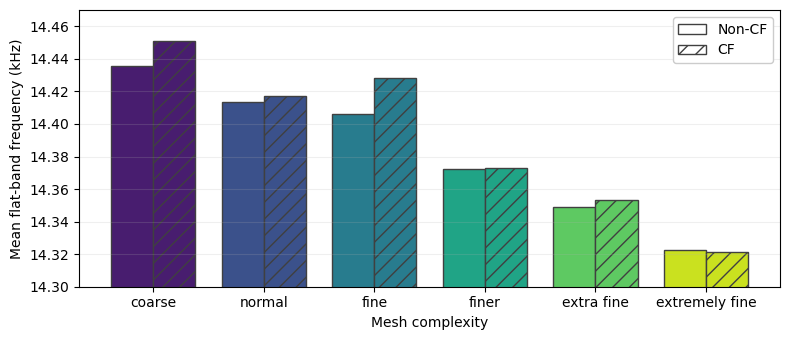

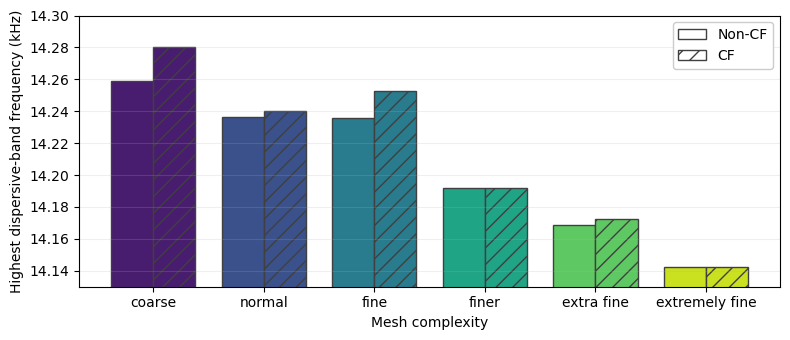

In [9]:
flat_frequencies_by_mesh = defaultdict(dict)
for label, metrics in flat_band_metrics.items():
    mesh_complexity, is_cf = mesh_variant(label)
    flat_frequencies_by_mesh[mesh_complexity][is_cf] = (
        metrics['mean_hz'] / 1e3
    )

paired_flat_frequencies = {
    mesh_complexity: frequencies
    for mesh_complexity, frequencies in flat_frequencies_by_mesh.items()
    if False in frequencies and True in frequencies
}
if not paired_flat_frequencies:
    raise ValueError('No paired CF and non-CF simulation files found')

paired_meshes = [
    mesh_complexity for mesh_complexity in mesh_complexities
    if mesh_complexity in paired_flat_frequencies
]
paired_mesh_colors = [mesh_colors[mesh] for mesh in paired_meshes]
bar_positions = np.arange(len(paired_meshes))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(8, 3.5), tight_layout=True)
ax.bar(
    bar_positions - bar_width / 2,
    [paired_flat_frequencies[mesh][False] for mesh in paired_meshes],
    width=bar_width, color=paired_mesh_colors,
    edgecolor='0.25', label='Non-CF',
)
ax.bar(
    bar_positions + bar_width / 2,
    [paired_flat_frequencies[mesh][True] for mesh in paired_meshes],
    width=bar_width, color=paired_mesh_colors,
    edgecolor='0.25', hatch='//', label='CF',
)

ax.set_xticks(
    bar_positions,
    [mesh_display_name(mesh) for mesh in paired_meshes],
)
ax.set_xlabel('Mesh complexity')
ax.set_ylabel('Mean flat-band frequency (kHz)')
ax.set_ylim(14.30, 14.47)
ax.grid(axis='y', alpha=0.2)
bar_legend_handles = [
    Patch(facecolor='white', edgecolor='0.25', label='Non-CF'),
    Patch(
        facecolor='white', edgecolor='0.25',
        hatch='//', label='CF',
    ),
]
ax.legend(
    handles=bar_legend_handles,
    frameon=True, facecolor='white', framealpha=1.0,
    edgecolor='0.8',
)
plt.show()

highest_dispersive_frequencies_by_mesh = defaultdict(dict)
for label, metrics in flat_band_metrics.items():
    mesh_complexity, is_cf = mesh_variant(label)
    highest_dispersive_frequencies_by_mesh[mesh_complexity][is_cf] = (
        metrics['highest_dispersive_hz'] / 1e3
    )

paired_highest_dispersive_frequencies = {
    mesh_complexity: frequencies
    for mesh_complexity, frequencies
    in highest_dispersive_frequencies_by_mesh.items()
    if False in frequencies and True in frequencies
}
if not paired_highest_dispersive_frequencies:
    raise ValueError('No paired CF and non-CF simulation files found')

paired_meshes = [
    mesh_complexity for mesh_complexity in mesh_complexities
    if mesh_complexity in paired_highest_dispersive_frequencies
]
paired_mesh_colors = [mesh_colors[mesh] for mesh in paired_meshes]
bar_positions = np.arange(len(paired_meshes))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(8, 3.5), tight_layout=True)
ax.bar(
    bar_positions - bar_width / 2,
    [
        paired_highest_dispersive_frequencies[mesh][False]
        for mesh in paired_meshes
    ],
    width=bar_width, color=paired_mesh_colors,
    edgecolor='0.25', label='Non-CF',
)
ax.bar(
    bar_positions + bar_width / 2,
    [
        paired_highest_dispersive_frequencies[mesh][True]
        for mesh in paired_meshes
    ],
    width=bar_width, color=paired_mesh_colors,
    edgecolor='0.25', hatch='//', label='CF',
)

ax.set_xticks(
    bar_positions,
    [mesh_display_name(mesh) for mesh in paired_meshes],
)
ax.set_xlabel('Mesh complexity')
ax.set_ylabel('Highest dispersive-band frequency (kHz)')
ax.set_ylim(14.13, 14.30)
ax.grid(axis='y', alpha=0.2)
ax.legend(
    handles=bar_legend_handles,
    frameon=True, facecolor='white', framealpha=1.0,
    edgecolor='0.8',
)
plt.show()